In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/home/sae-itoshi/projects/prosperity-4/data_capsule/ROUND_2/prices_round_2_day_0.csv", sep=";")

# print(df.columns)
# print(df.head())


osmium = df[df["product"] == "ASH_COATED_OSMIUM"].copy()
osmium = osmium.sort_values("timestamp")

osmium = osmium[
    (osmium["bid_price_1"] > 0) &
    (osmium["ask_price_1"] > 0)
]
osmium["mid"] = (osmium["bid_price_1"] + osmium["ask_price_1"]) / 2

osmium_sampled = osmium.iloc[::20]


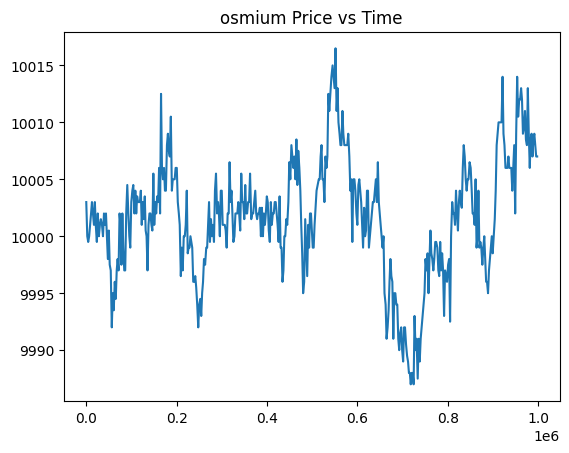

In [2]:
# plot 1 price vs time
plt.figure()
plt.plot(osmium_sampled["timestamp"], osmium_sampled["mid"])
plt.title("osmium Price vs Time")
plt.show()


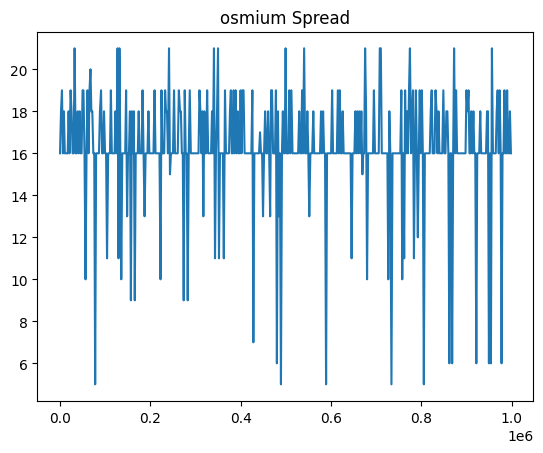

In [3]:
# plot 2 spread vs time
osmium["spread"] = osmium["ask_price_1"] - osmium["bid_price_1"]
osmium_sampled["spread"] = osmium_sampled["ask_price_1"] - osmium_sampled["bid_price_1"]

plt.figure()
# plt.plot(osmium["timestamp"], osmium["spread"])
plt.plot(osmium_sampled["timestamp"], osmium_sampled["spread"])
plt.title("osmium Spread")
plt.show()


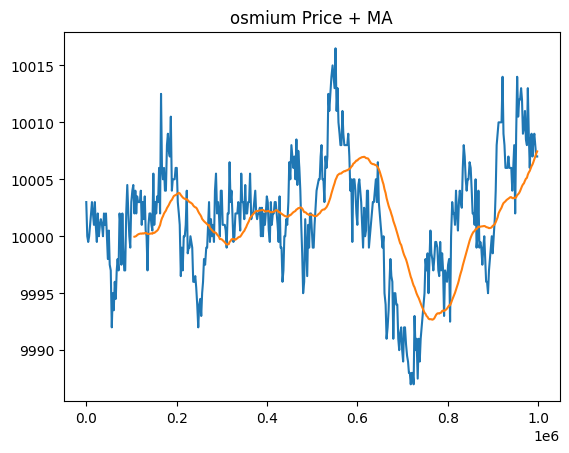

In [4]:
# plot 3 Moving Average
window = 50
osmium_sampled["ma"] = osmium_sampled["mid"].rolling(window).mean()
osmium["ma"] = osmium["mid"].rolling(window).mean()

plt.figure()
plt.plot(osmium_sampled["timestamp"], osmium_sampled["mid"])
plt.plot(osmium_sampled["timestamp"], osmium_sampled["ma"])
# plt.plot(osmium["timestamp"], osmium["mid"])
# plt.plot(osmium["timestamp"], osmium["ma"])
plt.title("osmium Price + MA")
plt.show()

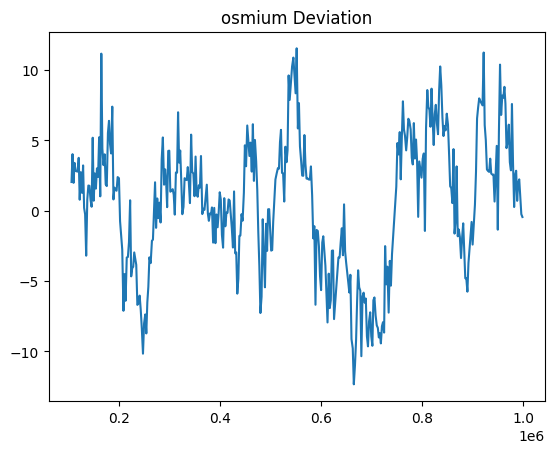

In [5]:
# plot 4 deviation
osmium["dev"] = osmium["mid"] - osmium["ma"]
osmium_sampled["dev"] = osmium_sampled["mid"] - osmium_sampled["ma"]

plt.figure()
plt.plot(osmium_sampled["timestamp"], osmium_sampled["dev"])
# plt.plot(osmium["timestamp"], osmium["dev"])
plt.title("osmium Deviation")
plt.show()

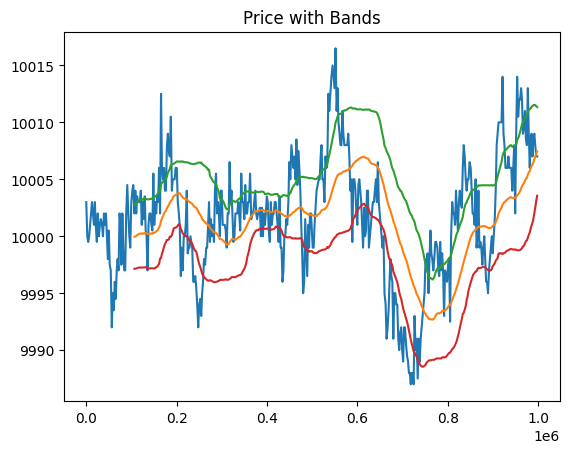

In [6]:
# trying something else
osmium_sampled["std"] = osmium_sampled["mid"].rolling(window).std()
osmium["std"] = osmium["mid"].rolling(window).std()

plt.figure()
plt.plot(osmium_sampled["timestamp"], osmium_sampled["mid"])
plt.plot(osmium_sampled["timestamp"], osmium_sampled["ma"])
plt.plot(osmium_sampled["timestamp"], osmium_sampled["ma"] + osmium_sampled["std"])
plt.plot(osmium_sampled["timestamp"], osmium_sampled["ma"] - osmium_sampled["std"])
plt.title("Price with Bands")
plt.show()

In [7]:
osmium["returns"] = osmium["mid"].diff()

print("Average drift per tick:", osmium["returns"].mean())
print("Deviation mean:", osmium["dev"].mean())
print("Deviation std:", osmium["dev"].std())
print("Deviation min:", osmium["dev"].min())
print("Deviation max:", osmium["dev"].max())
print("Average spread:", osmium["spread"].mean())

Average drift per tick: 0.00054019014693172
Deviation mean: 0.017591225021715257
Deviation std: 1.8431712042951043
Deviation min: -8.719999999999345
Deviation max: 8.709999999999127
Average spread: 16.249540887976668


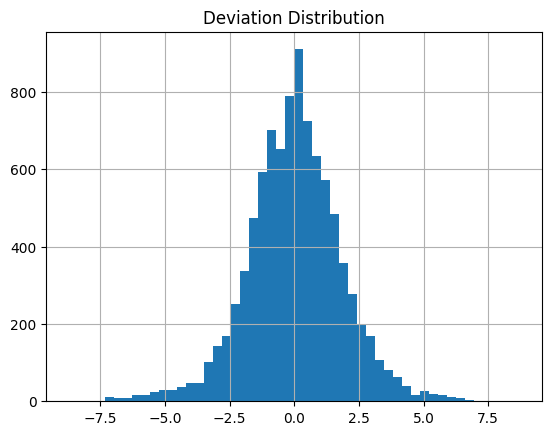

In [8]:
osmium["dev"].hist(bins=50)
plt.title("Deviation Distribution")
plt.show()

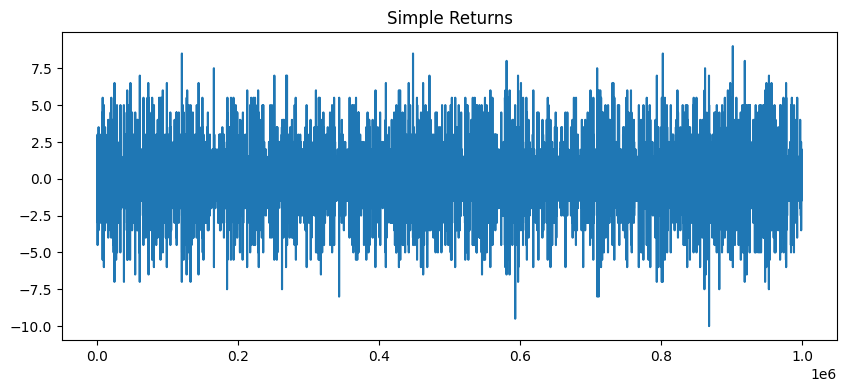

In [9]:
import numpy as np

osmium["return"] = osmium["mid"].diff()
osmium["log_return"] = np.log(osmium["mid"] / osmium["mid"].shift(1))

plt.figure(figsize=(10,4))
plt.plot(osmium["timestamp"], osmium["return"])
plt.title("Simple Returns")
plt.show()

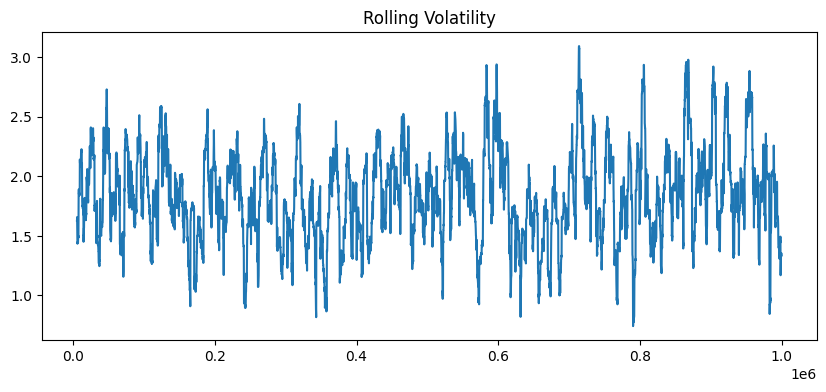

In [10]:
window = 50

osmium["volatility"] = osmium["return"].rolling(window).std()

plt.figure(figsize=(10,4))
plt.plot(osmium["timestamp"], osmium["volatility"])
plt.title("Rolling Volatility")
plt.show()

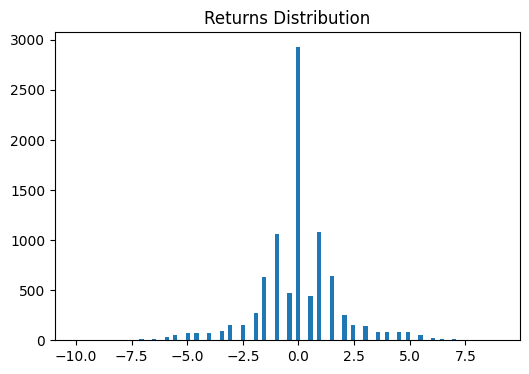

In [11]:
plt.figure(figsize=(6,4))
plt.hist(osmium["return"].dropna(), bins=100)
plt.title("Returns Distribution")
plt.show()

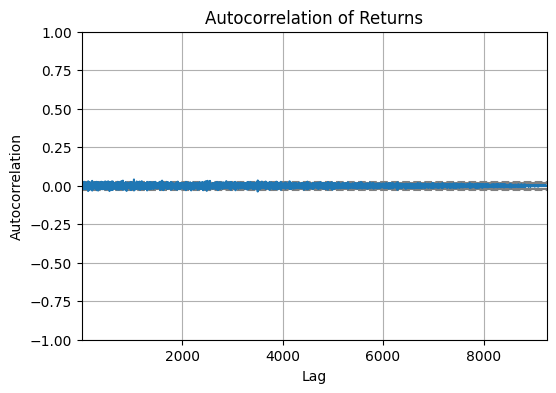

In [12]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(6,4))
autocorrelation_plot(osmium["return"].dropna())
plt.title("Autocorrelation of Returns")
plt.show()

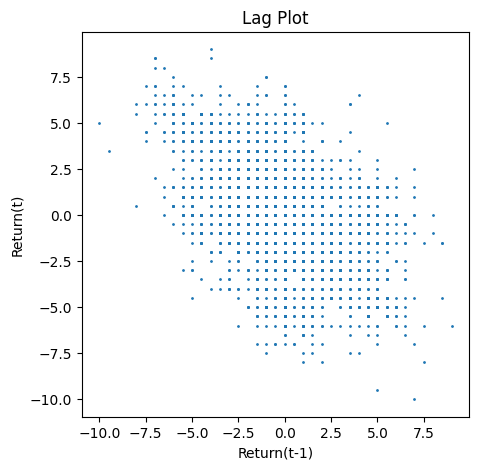

In [13]:
plt.figure(figsize=(5,5))
plt.scatter(osmium["return"].shift(1), osmium["return"], s=1)
plt.xlabel("Return(t-1)")
plt.ylabel("Return(t)")
plt.title("Lag Plot")
plt.show()

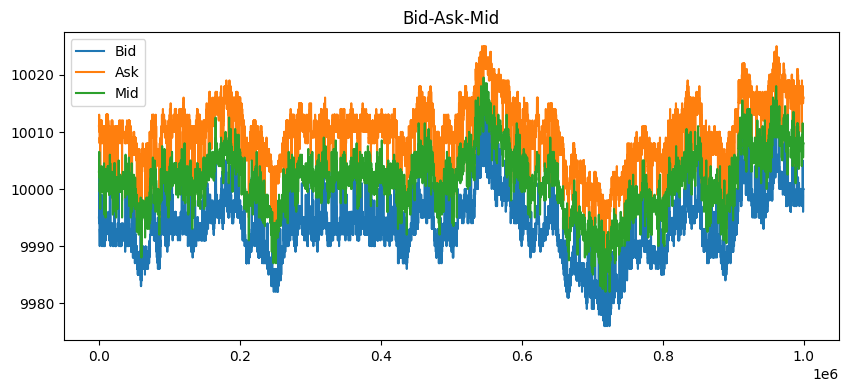

In [14]:
plt.figure(figsize=(10,4))
plt.plot(osmium["timestamp"], osmium["bid_price_1"], label="Bid")
plt.plot(osmium["timestamp"], osmium["ask_price_1"], label="Ask")
plt.plot(osmium["timestamp"], osmium["mid"], label="Mid")
plt.legend()
plt.title("Bid-Ask-Mid")
plt.show()

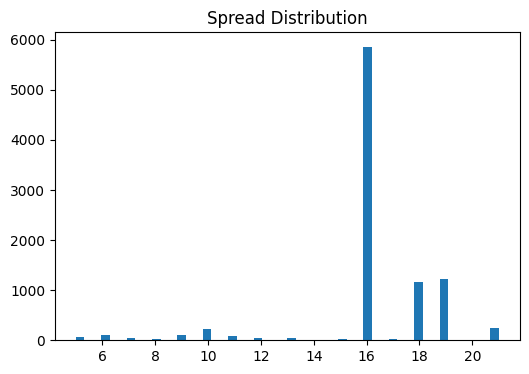

In [15]:
osmium["spread"] = osmium["ask_price_1"] - osmium["bid_price_1"]

plt.figure(figsize=(6,4))
plt.hist(osmium["spread"], bins=50)
plt.title("Spread Distribution")
plt.show()

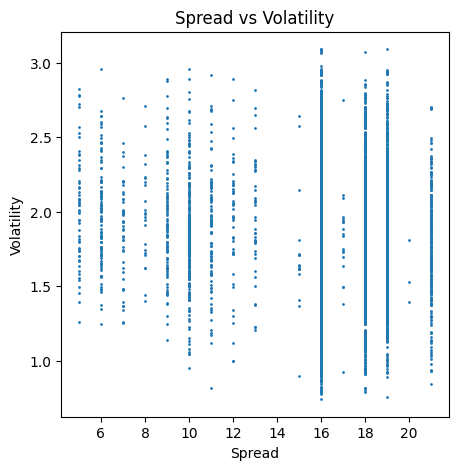

In [16]:
plt.figure(figsize=(5,5))
plt.scatter(osmium["spread"], osmium["volatility"], s=1)
plt.xlabel("Spread")
plt.ylabel("Volatility")
plt.title("Spread vs Volatility")
plt.show()

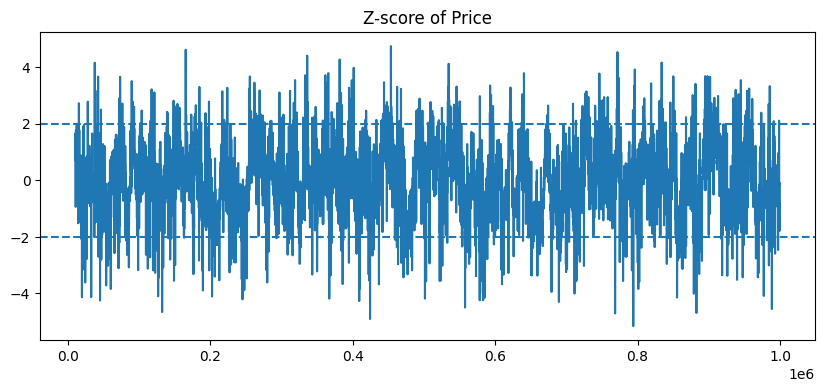

In [17]:
window = 100

rolling_mean = osmium["mid"].rolling(window).mean()
rolling_std = osmium["mid"].rolling(window).std()

osmium["zscore"] = (osmium["mid"] - rolling_mean) / rolling_std

plt.figure(figsize=(10,4))
plt.plot(osmium["timestamp"], osmium["zscore"])
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.title("Z-score of Price")
plt.show()

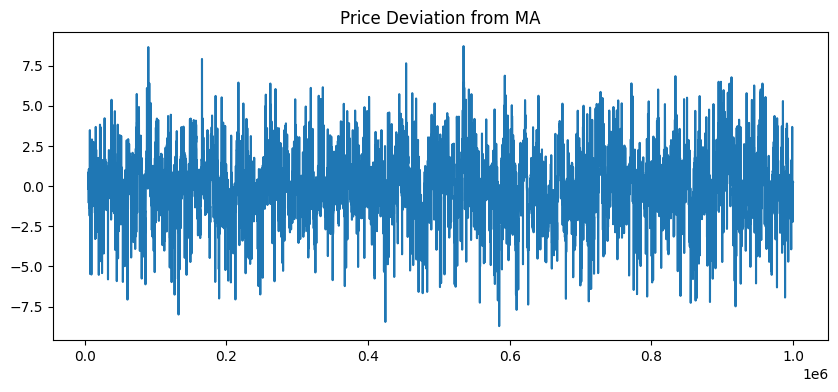

In [18]:
osmium["ma"] = osmium["mid"].rolling(50).mean()
osmium["deviation"] = osmium["mid"] - osmium["ma"]

plt.figure(figsize=(10,4))
plt.plot(osmium["timestamp"], osmium["deviation"])
plt.title("Price Deviation from MA")
plt.show()

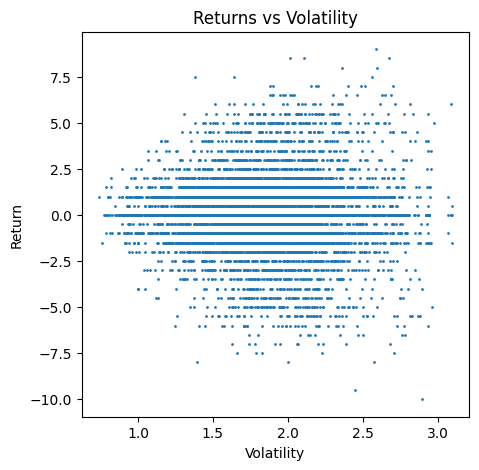

In [19]:
plt.figure(figsize=(5,5))
plt.scatter(osmium["volatility"], osmium["return"], s=1)
plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Returns vs Volatility")
plt.show()

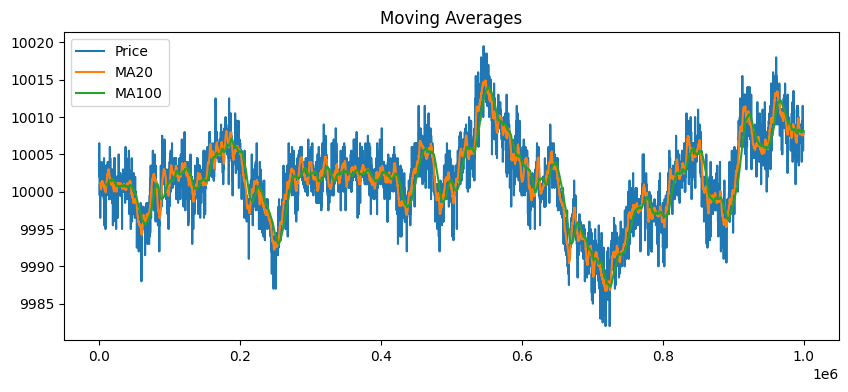

In [20]:
osmium["ma_short"] = osmium["mid"].rolling(20).mean()
osmium["ma_long"] = osmium["mid"].rolling(100).mean()

plt.figure(figsize=(10,4))
plt.plot(osmium["timestamp"], osmium["mid"], label="Price")
plt.plot(osmium["timestamp"], osmium["ma_short"], label="MA20")
plt.plot(osmium["timestamp"], osmium["ma_long"], label="MA100")
plt.legend()
plt.title("Moving Averages")
plt.show()

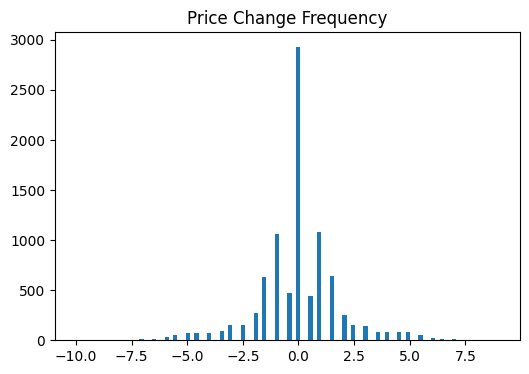

In [21]:
price_changes = osmium["mid"].diff()

plt.figure(figsize=(6,4))
plt.hist(price_changes.dropna(), bins=100)
plt.title("Price Change Frequency")
plt.show()

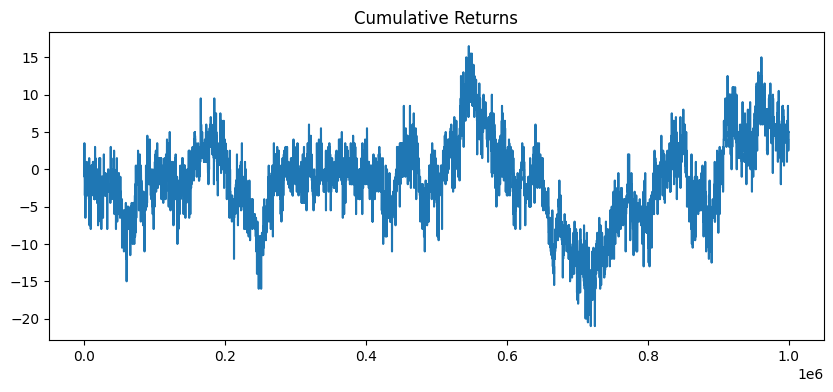

In [22]:
osmium["cum_return"] = osmium["return"].cumsum()

plt.figure(figsize=(10,4))
plt.plot(osmium["timestamp"], osmium["cum_return"])
plt.title("Cumulative Returns")
plt.show()

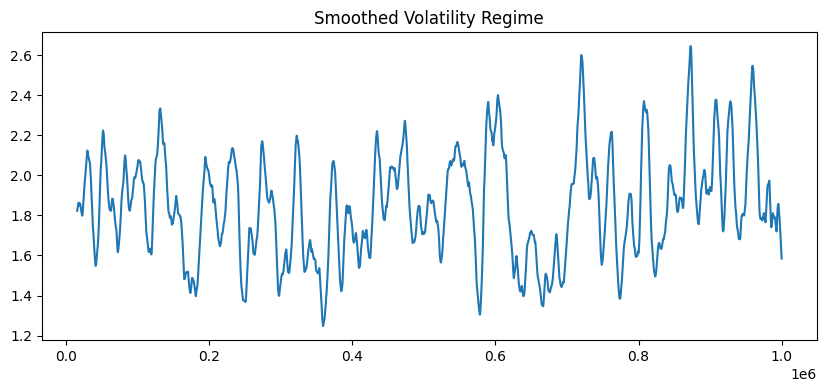

In [23]:
osmium["vol_smooth"] = osmium["volatility"].rolling(100).mean()

plt.figure(figsize=(10,4))
plt.plot(osmium["timestamp"], osmium["vol_smooth"])
plt.title("Smoothed Volatility Regime")
plt.show()